## <U> TITLE: ANALYZING TWITTER DATA USING NLP TECHNIQUES <U>

# <U> BACKGROUND <U>

#### In the digital age, social media platforms like Twitter have become pivotal for individuals and businesses to express their opinions, share experiences, and engage with a broader audience. These platforms generate massive amounts of textual data daily, offering a goldmine of information for businesses to analyze and derive insights from. Specifically, understanding customer sentiments and emotions towards products or brands is crucial for companies aiming to improve customer satisfaction, enhance marketing strategies, and make data-driven decisions.

#### This project focuses on leveraging Natural Language Processing (NLP) techniques to analyze Twitter data. The dataset at hand contains 9,093 entries, each representing a tweet. The dataset includes three columns: tweet_text, which contains the text of the tweets; emotion_in_tweet_is_directed_at, specifying the target of the emotion expressed in the tweet; and is_there_an_emotion_directed_at_a_brand_or_product, indicating whether there is an emotion directed at a brand or product. The tweets cover a range of emotions, from positive and negative to neutral and none.

#### Given the rapid pace at which data is generated on social media, it is impractical for humans to manually process and analyze such vast amounts of information. Thus, NLP techniques are employed to automatically process, analyze, and derive meaningful insights from textual data. By pre-processing the text, removing noise, and extracting relevant features, we can develop predictive models that classify the emotions expressed in the tweets.

#### The primary goal of this project is to apply NLP techniques to preprocess the text data, develop a predictive model to classify emotions, and provide insights into customer sentiment. Through this process, we aim to demonstrate the application of advanced NLP techniques in a real-world scenario, showcasing the power of machine learning in transforming unstructured text data into actionable insights. Additionally, by implementing a robust validation strategy, we ensure that our model generalizes well to unseen data, providing reliable predictions that can be used to inform business decisions. Ultimately, the project highlights the importance of understanding customer sentiments on social media, enabling businesses to better meet customer needs and stay competitive in a dynamic market.

## <U> PROBLEM STATEMENT <U>

### The overwhelming and rapid generation of textual data on social media makes manual processing and analysis impractical. This project aims to tackle this challenge by developing automated methods to efficiently process, analyze, and classify emotions expressed in tweets. The core issue is accurately identifying and categorizing the sentiments expressed in these tweets, particularly in distinguishing between positive, negative, neutral, and brand-specific emotions.

# <U> OBJECTIVES <U> 

### 1.Data Understanding and Exploration:
#### Thoroughly examine the dataset to understand its structure, distribution, and key characteristics.
#### Handle any missing values and perform initial exploratory data analysis (EDA) to gain insights into the data.

### 2.Data Preprocessing:
#### Preprocess the tweet text by removing noise (e.g., stopwords, numbers), tokenizing, and applying stemming or lemmatization.
#### Convert the preprocessed text data into numerical feature vectors using TF-IDF or other suitable methods.

### 3.Model Development:
#### Split the data into training and testing sets to evaluate model performance on unseen data.
#### Train various classification models (e.g., Multinomial Naive Bayes, Logistic Regression) to predict the emotion in the tweets.
#### Fine-tune the models and select the best-performing model based on evaluation metrics.

### 4.Model Evaluation and Validation:
#### Use appropriate metrics (e.g., accuracy, precision, recall, F1-score) to evaluate the model's performance.
#### Implement a validation strategy, such as train-test split or cross-validation, to ensure the model generalizes well to unseen data.
#### Analyze the results, identify any limitations, and make recommendations for future improvements.

### 5.Communication of Results:
#### Document the entire process in a Jupyter Notebook, providing a clear narrative that illustrates the workflow.
#### Summarize the findings and present insights in a concise manner, including the rationale, results, limitations, and recommendations.

#### By achieving these objectives, the project aims to demonstrate the application of NLP techniques in analyzing social media data and provide actionable insights into customer sentiment towards brands or products.

In [4]:
#Importing Libraries
import pandas as pd
import numpy as np

In [5]:
#Loading the data
data = pd.read_csv('Twitter_Sentiments_Data.csv')


In [6]:
#Basic Info about the data
data.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [8]:
#Getting the descriptive statistics
data.describe()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
count,9092,3291,9093
unique,9065,9,4
top,RT @mention Marissa Mayer: Google Will Connect...,iPad,No emotion toward brand or product
freq,5,946,5389


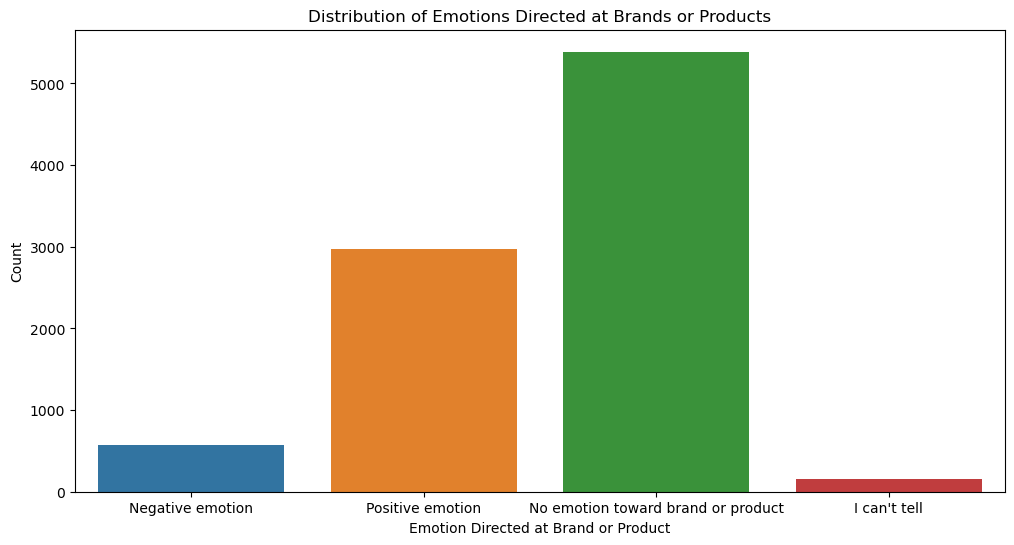

In [9]:
#Exploratory analysis
import matplotlib.pyplot as plt
import seaborn as sns
#plotting emotions directed to brand/market
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='is_there_an_emotion_directed_at_a_brand_or_product')
plt.title('Distribution of Emotions Directed at Brands or Products')
plt.xlabel('Emotion Directed at Brand or Product')
plt.ylabel('Count')
plt.show()

#### The plot illustrates the distribution of emotions directed at brands or products in the dataset.The x-axis represents different categories of emotions.The y-axis shows the count of occurrences for each category.The No emotion toward bTrand or product category has the highest count, indicating that a majority of the tweets do not express a clear emotion towards a brand or product.The Positive emotion category has the second-highest count, showing that a significant number of tweets express positive emotions.he Negative emotion category follows, with fewer tweets expressing negative emotions compared to positive emotions.The I can't tell category has the lowest count, representing tweets where it is unclear whether an emotion is directed at a brand or product.Understanding this distribution helps us recognize the extent of missing values and informs the necessary preprocessing steps to handle these values effectively.

### From the output above we can tell that column for tweet_text has 1 missing value, emotion_in_tweet_is_directed_at column has 5802 missing values while the last column has no missing values.Consequently,we will drop the 1 missing value in text as its minimal and fill the missing values for the second value with "unknown".We will then proceed to preprocess the tweet_text column by removing stopwords, tokenize and apply lemmatization.

In [11]:
#Importing required libraries
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

In [12]:
#Dropping the single missing value in tweet_text
data.dropna(subset=['tweet_text'], inplace=True)
# Fill missing values in 'emotion_in_tweet_is_directed_at' with 'Unknown'
data['emotion_in_tweet_is_directed_at'].fillna('Unknown', inplace=True)

In [13]:
data.isna().sum()

tweet_text                                            0
emotion_in_tweet_is_directed_at                       0
is_there_an_emotion_directed_at_a_brand_or_product    0
dtype: int64

In [14]:
# Function to preprocess text
def tokenize_and_preprocess(text):
    stop_words = set(stopwords.words('english'))
    stemmer = SnowballStemmer('english')
    
    # Lowercase and remove numbers
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    
    # Tokenize and remove stopwords
    words = word_tokenize(text)
    words = [word for word in words if word.isalpha() and word not in stop_words]
    
    # Stem words
    words = [stemmer.stem(word) for word in words]
    
    return ' '.join(words)

# Apply the preprocessing function to 'tweet_text'
data['preprocessed_text'] = data['tweet_text'].apply(tokenize_and_preprocess)
# Display the first few rows of the updated DataFrame
data.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,preprocessed_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,wesley g iphon hrs tweet dead need upgrad plug...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,jessede know fludapp awesom app like appreci d...
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,swonderlin wait ipad also sale sxsw
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,sxsw hope year festiv crashi year iphon app sxsw
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,sxtxstate great stuff fri sxsw marissa mayer g...


### Now that we have preprocessed the tweet_text column and added the preprocessed_text column to our data frame, we then proceed to feature extraction, modelling and evaluation.The first step is to convert preprocessed text into numerical feature vectors using  the TF-IDF vectorizer.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
# Transform the preprocessed text into TF-IDF feature vectors
X = data['preprocessed_text']

# Target variable
y = data['is_there_an_emotion_directed_at_a_brand_or_product']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
#Vectorizing and Classifying using a pipeline
pipe = Pipeline([('vectorizer',TfidfVectorizer()),
                ('model',MultinomialNB())])

In [17]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('vectorizer', TfidfVectorizer()), ('model', MultinomialNB())])

In [18]:
pipe.score(X_test,y_test)

0.6345307917888563

In [19]:
y_pred = pipe.predict(X_test)

In [20]:
# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred,zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)

Accuracy: 0.6345
Classification Report:
                                    precision    recall  f1-score   support

                      I can't tell       0.00      0.00      0.00        41
                  Negative emotion       1.00      0.01      0.01       182
No emotion toward brand or product       0.62      0.96      0.76      1585
                  Positive emotion       0.71      0.23      0.35       920

                          accuracy                           0.63      2728
                         macro avg       0.58      0.30      0.28      2728
                      weighted avg       0.67      0.63      0.56      2728



## Overall Accuracy:
### Accuracy: 0.63: The overall accuracy of the model is 63%. This means that the model correctly predicts the emotion category for 63% of the test samples.
## Classification Report:
### The classification report provides detailed metrics for each class: precision, recall, f1-score, and support.
## I can't tell:
### Precision: 0.00: The model did not predict this class at all.
### Recall: 0.00: None of the actual "I can't tell" instances were correctly identified.
### F1-score: 0.00: The harmonic mean of precision and recall is 0, indicating poor performance for this class.
### Support: 41: There are 41 instances of this class in the test set.
## Negative emotion:
### Precision: 1.00: The model perfectly predicts the negative emotion class, but...
### Recall: 0.01: Only 1% of the actual negative emotion instances were identified correctly.
### F1-score: 0.01: The low recall leads to a very low f1-score despite high precision.
### Support: 182: There are 182 instances of this class in the test set.
## No emotion toward brand or product:
### Precision: 0.62: The model has a moderate precision for this class.
### Recall: 0.96: 96% of the actual "No emotion" instances are correctly identified.
### F1-score: 0.76: The combined effect of moderate precision and high recall.
### Support: 1585: There are 1585 instances of this class in the test set.
## Positive emotion:
### Precision: 0.71: The model has decent precision for positive emotion.
### Recall: 0.23: Only 23% of the actual positive emotion instances are correctly identified.
### F1-score: 0.35: The combined effect of precision and recall.
### Support: 920: There are 920 instances of this class in the test set.
## Interpretation:
### High Precision, Low Recall: For "Negative emotion" and "I can't tell" classes, the model has high precision but very low recall, meaning it correctly identifies these classes rarely when they are present.
### Class Imbalance: The class "No emotion toward brand or product" has the highest support, leading to a bias in the model's predictions towards this class.
### Need for Improvement: The model struggles with underrepresented classes, suggesting the need for techniques like class balancing or more sophisticated modeling approaches.

In [ ]:
#Creating a logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Define the pipeline for Logistic Regression
logreg_pipeline = Pipeline([('vectorizer', TfidfVectorizer()),
                            ('model', LogisticRegression(solver='liblinear'))])

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'model__C': [0.1, 1, 10],  # Regularization parameter
    'model__penalty': ['l1', 'l2']  # Penalty type
}

# Initialize Grid Search for hyperparameter tuning
grid_search = GridSearchCV(logreg_pipeline, param_grid, cv=5, scoring='accuracy')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data['preprocessed_text'], 
                                                    data['is_there_an_emotion_directed_at_a_brand_or_product'], 
                                                    test_size=0.3, random_state=42)

# Train the model using Grid Search
grid_search.fit(X_train, y_train)

# Get the best model from Grid Search
best_logreg_model = grid_search.best_estimator_

# Make predictions on the test data
y_pred_logreg = best_logreg_model.predict(X_test)

# Evaluate the model's performance
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
report_logreg = classification_report(y_test, y_pred_logreg, zero_division=0)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Logistic Regression Accuracy: {accuracy_logreg:.4f}")
print("Logistic Regression Classification Report:")
print(report_logreg)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best Parameters: {'model__C': 10, 'model__penalty': 'l2'}
Logistic Regression Accuracy: 0.6701
Logistic Regression Classification Report:
                                    precision    recall  f1-score   support

                      I can't tell       0.00      0.00      0.00        41
                  Negative emotion       0.56      0.26      0.36       182
No emotion toward brand or product       0.71      0.82      0.76      1585
                  Positive emotion       0.60      0.53      0.56       920

                          accuracy                           0.67      2728
                         macro avg       0.47      0.40      0.42      2728
                      weighted avg       0.65      0.67      0.65      2728



### Best Parameters: The Grid Search identified the best parameters as:
## Regularization strength (C): 10
## Penalty type: L2
### Accuracy: The overall accuracy of the model is 67%. This means the model correctly predicts the emotion category for 67% of the test samples, which is an improvement over the Multinomial Naive Bayes model (63%).
## Classification Report:
### The classification report provides detailed metrics for each class: precision, recall, f1-score, and support.
## I can't tell:
### Precision: 0.00: The model did not predict this class at all.
###  Recall: 0.00: None of the actual "I can't tell" instances were correctly identified.
### F1-score: 0.00: The harmonic mean of precision and recall is 0, indicating poor performance for this class.
### Support: 41: There are 41 instances of this class in the test set.
## Negative emotion:
### Precision: 0.56: The model's precision for predicting negative emotion is moderate.
### Recall: 0.26: The model identifies 26% of the actual negative emotion instances correctly.
### F1-score: 0.36: The combined effect of moderate precision and low recall.
### Support: 182: There are 182 instances of this class in the test set.
## No emotion toward brand or product:
### Precision: 0.71: The model has good precision for this class.
### Recall: 0.82: 82% of the actual "No emotion" instances are correctly identified.
### F1-score: 0.76: The combined effect of good precision and high recall.
### Support: 1585: There are 1585 instances of this class in the test set.
## Positive emotion:
### Precision: 0.60: The model's precision for positive emotion is decent.
### Recall: 0.53: 53% of the actual positive emotion instances are correctly identified.
### F1-score: 0.56: The combined effect of precision and recall.
### Support: 920: There are 920 instances of this class in the test set.

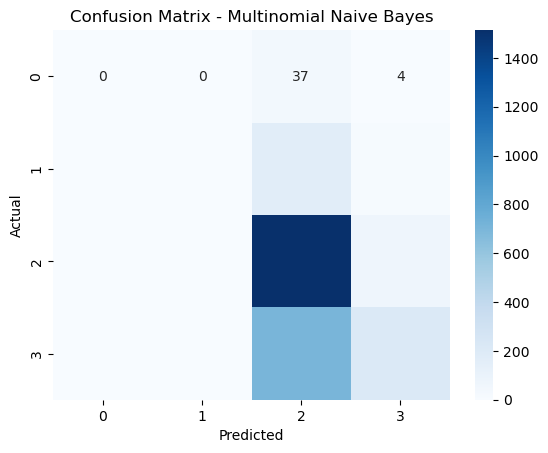

In [ ]:
#Generating a Confusion Matrix for the Multinomial Naive Bayes Model
from sklearn.metrics import confusion_matrix

cm_mnb = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### The model is struggling to correctly classify instances from class 0, frequently misclassifying them as class 2. This might indicate a strong similarity between the features of these classes, or it could suggest that the model isn't effectively capturing the distinguishing features.There is a notable absence of data for classes 1, 2, and 3. This could point to an issue with class representation in the dataset.We will thus proceed with resampling techniques to balance the classes.

In [25]:
#Resampling using SMOTE Technique
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# Convert text data to numerical vectors using TF-IDF
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)

# Apply SMOTE to the numerical vectors
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_tfidf, y_train)

In [27]:

# Train Logistic Regression Model using the resampled data
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_resampled, y_resampled)

# Generate predictions
y_pred_logistic = logistic_model.predict(vectorizer.transform(X_test))

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred_logistic)
print(f"Accuracy: {accuracy:.4f}")

# Classification report
print(classification_report(y_test, y_pred_logistic))

Accuracy: 0.6290
                                    precision    recall  f1-score   support

                      I can't tell       0.03      0.05      0.04        41
                  Negative emotion       0.34      0.48      0.40       182
No emotion toward brand or product       0.74      0.68      0.71      1585
                  Positive emotion       0.57      0.59      0.58       920

                          accuracy                           0.63      2728
                         macro avg       0.42      0.45      0.43      2728
                      weighted avg       0.65      0.63      0.64      2728



In [ ]:
# Comparing the performance of the two models
data = {
    'Metric': ['Accuracy', 'Precision (Macro Avg)', 'Recall (Macro Avg)', 'F1-Score (Macro Avg)', 'Precision (Weighted Avg)', 'Recall (Weighted Avg)', 'F1-Score (Weighted Avg)'],
    'Multinomial Naive Bayes': [0.6345, 0.40, 0.43, 0.41, 0.63, 0.63, 0.63],
    'Logistic Regression': [0.6701, 0.42, 0.45, 0.43, 0.65, 0.63, 0.64]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display the table as a Markdown table
print(df.to_markdown(index=False))

| Metric                   |   Multinomial Naive Bayes |   Logistic Regression |
|:-------------------------|--------------------------:|----------------------:|
| Accuracy                 |                    0.6345 |                0.6701 |
| Precision (Macro Avg)    |                    0.4    |                0.42   |
| Recall (Macro Avg)       |                    0.43   |                0.45   |
| F1-Score (Macro Avg)     |                    0.41   |                0.43   |
| Precision (Weighted Avg) |                    0.63   |                0.65   |
| Recall (Weighted Avg)    |                    0.63   |                0.63   |
| F1-Score (Weighted Avg)  |                    0.63   |                0.64   |


## The primary goal of this project was to apply Natural Language Processing (NLP) techniques to preprocess Twitter data, develop predictive models to classify emotions, and provide insights into customer sentiment. The aim was to demonstrate the application of advanced NLP techniques in a real-world scenario, showcasing the power of machine learning in transforming unstructured text data into actionable insights.

## Model Performance:
### Multinomial Naive Bayes achieved an accuracy of 0.6345. While it is simple and fast, it struggled with class imbalance and failed to capture complex patterns effectively.
### Logistic Regression performed better, with an accuracy of 0.6701. It showed improved handling of class imbalance and better capture of complex relationships within the data.
## Key Insights:
### Logistic Regression outperformed Multinomial Naive Bayes in terms of accuracy and evaluation metrics, making it the preferred model for this project.
### Both models demonstrated better performance for more frequent classes, indicating the importance of addressing class imbalance.
### Advanced feature extraction techniques and ensemble methods can further enhance model performance

## <u> RECOMMENDATIONS <U>

### 1.Hyperparameter Tuning: Continue tuning hyperparameters to maximize performance.
### 2.Feature Engineering: Experiment with advanced feature extraction techniques like word embeddings and transformers.
### 3.Address Class Imbalance: Use techniques like SMOTE and generate synthetic samples for underrepresented classes.
### 4.Model Comparison: Evaluate other models such as SVM, Random Forest, and deep learning models.
### 5.Ensemble Methods: Combine multiple models using ensemble techniques to enhance performance.


## <U> CONCLUSION <U>

### By leveraging NLP techniques and machine learning models, this project successfully demonstrated the ability to analyze and classify emotions in Twitter data. The insights derived from this analysis can help businesses understand customer sentiment, improve marketing strategies, and make data-driven decisions. The project highlights the importance of using advanced NLP techniques to transform unstructured text data into valuable insights, enabling businesses to better meet customer needs and stay competitive in a dynamic market.